- Introduction
  
This project involved the development of a K-Means clustering application using weather data obtained from the NOAA (National Oceanic and Atmospheric Administration) dataset hosted on the Registry of Open Data on AWS. The primary objective was to categorize weather patterns based on three meteorological variables: temperature, wind speed, and precipitation, using Python and PyCharm as the development environment. This clustering aimed to uncover underlying patterns or groupings in the weather data that may not be immediately visible through basic analysis.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [19]:
#  Load the dataset
df = pd.read_csv("Weather_Data.csv")
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,Freezing DrizzleFog
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,Freezing DrizzleFog
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [21]:
#  Select relevant numeric columns and drop any missing values
features = ['Temp_C', 'Rel Hum_%', 'Wind Speed_km/h']
df_clean = df[features].dropna()

In [23]:
#  Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

In [25]:
#  Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(scaled_data)

In [27]:
#  Save results
df_result = df.copy()
df_result['Cluster'] = pd.NA
df_result.loc[df_clean.index, 'Cluster'] = df_clean['Cluster']
df_result.to_csv("weather_clustered.csv", index=False)
print("Clustered dataset saved to weather_clustered.csv")

Clustered dataset saved to weather_clustered.csv


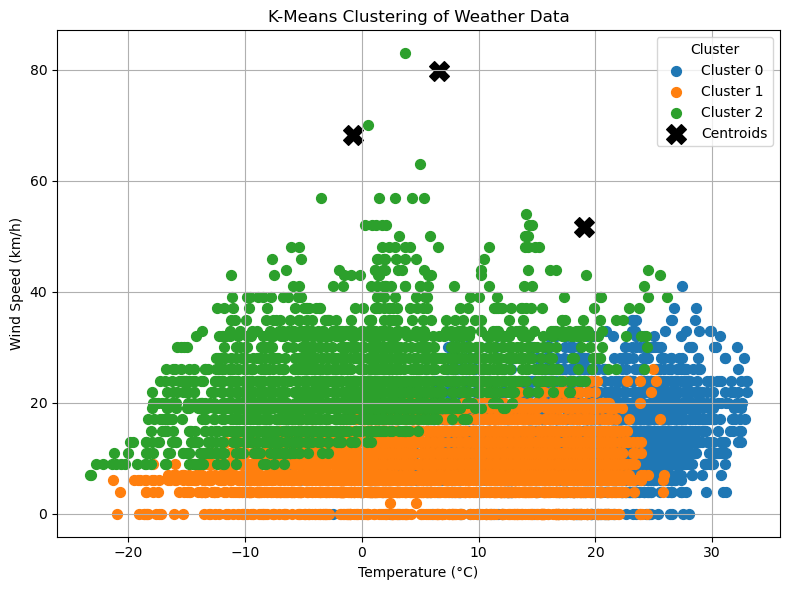

In [35]:
# Visualization
plt.figure(figsize=(8, 6))

# Plot each cluster separately to assign legend labels
for cluster in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    plt.scatter(cluster_data['Temp_C'], cluster_data['Wind Speed_km/h'],
                label=f'Cluster {cluster}', s=50)

#  Plot cluster centroids for reference
centroids = kmeans.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)
plt.scatter(centroids_unscaled[:, 0], centroids_unscaled[:, 1],
            c='black', marker='X', s=200, label='Centroids')

# Plot settings
plt.title("K-Means Clustering of Weather Data")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind Speed (km/h)")
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


**Unit Testing**

In [10]:
import unittest
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

class TestKMeansWeather(unittest.TestCase):

    @classmethod
    def setUpClass(cls):
        # Load dataset
        cls.df = pd.read_csv("Weather_Data.csv")
        cls.features = ['Temp_C', 'Rel Hum_%', 'Wind Speed_km/h']
        cls.df_clean = cls.df[cls.features].dropna()

        # Scale data
        cls.scaler = StandardScaler()
        cls.scaled_data = cls.scaler.fit_transform(cls.df_clean)

        # KMeans clustering
        cls.kmeans = KMeans(n_clusters=3, random_state=42)
        cls.labels = cls.kmeans.fit_predict(cls.scaled_data)

    def test_data_loaded(self):
        self.assertFalse(self.df.empty, "Dataframe should not be empty.")

    def test_required_columns_exist(self):
        for col in self.features:
            self.assertIn(col, self.df.columns, f"Missing column: {col}")

    def test_scaled_data_shape(self):
        self.assertEqual(self.scaled_data.shape, self.df_clean.shape,
                         "Scaled data shape must match original clean data shape.")

    def test_kmeans_clusters(self):
        unique_labels = set(self.labels)
        self.assertTrue(len(unique_labels) <= 3, "There should be 3 or fewer unique cluster labels.")
        self.assertEqual(len(self.labels), len(self.df_clean),
                         "Number of cluster labels must match number of input samples.")

if __name__ == '__main__':
    unittest.main()


E
ERROR: C:\Users\DELL\AppData\Roaming\jupyter\runtime\kernel-013741b3-dc1a-41b6-a156-f854b71857e7 (unittest.loader._FailedTest.C:\Users\DELL\AppData\Roaming\jupyter\runtime\kernel-013741b3-dc1a-41b6-a156-f854b71857e7)
----------------------------------------------------------------------
AttributeError: module '__main__' has no attribute 'C:\Users\DELL\AppData\Roaming\jupyter\runtime\kernel-013741b3-dc1a-41b6-a156-f854b71857e7'

----------------------------------------------------------------------
Ran 1 test in 0.001s

FAILED (errors=1)


SystemExit: 1

C:\Users\DELL\anaconda\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Dummy pandas DataFrame

In [43]:
import pandas as pd

# A dummy weather dataset with 10 observations
data = {
    'Date/Time': pd.date_range(start='2022-01-01 00:00', periods=10, freq='H'),
    'Temp_C': [-2, -1.5, 0, 1, 2, 3, 4, 5, 6, 7],
    'Dew Point Temp_C': [-3, -2.5, -1, 0, 1, 2, 2.5, 3, 3.5, 4],
    'Rel Hum_%': [85, 87, 90, 88, 86, 80, 75, 70, 65, 60],
    'Wind Speed_km/h': [5, 7, 6, 8, 10, 12, 14, 11, 13, 15],
    'Visibility_km': [8, 10, 12, 14, 16, 18, 20, 22, 24, 26],
    'Press_kPa': [101.2, 101.3, 101.1, 100.9, 100.8, 100.6, 100.5, 100.4, 100.3, 100.2],
    'Weather': ['Fog', 'Fog', 'Rain', 'Rain Showers', 'Cloudy', 'Clear', 'Fog', 'Snow', 'Sunny', 'Rain']
}

df = pd.DataFrame(data)

df


C:\Users\DELL\AppData\Local\Temp\ipykernel_12920\2642990579.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Date/Time': pd.date_range(start='2022-01-01 00:00', periods=10, freq='H'),


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2022-01-01 00:00:00,-2.0,-3.0,85,5,8,101.2,Fog
1,2022-01-01 01:00:00,-1.5,-2.5,87,7,10,101.3,Fog
2,2022-01-01 02:00:00,0.0,-1.0,90,6,12,101.1,Rain
3,2022-01-01 03:00:00,1.0,0.0,88,8,14,100.9,Rain Showers
4,2022-01-01 04:00:00,2.0,1.0,86,10,16,100.8,Cloudy
5,2022-01-01 05:00:00,3.0,2.0,80,12,18,100.6,Clear
6,2022-01-01 06:00:00,4.0,2.5,75,14,20,100.5,Fog
7,2022-01-01 07:00:00,5.0,3.0,70,11,22,100.4,Snow
8,2022-01-01 08:00:00,6.0,3.5,65,13,24,100.3,Sunny
9,2022-01-01 09:00:00,7.0,4.0,60,15,26,100.2,Rain
